## Install libraries and packages

In [1]:
#Install packages into kernel's enviornment
%pip install seaborn scikit-learn
%pip install -e '../../decipher-bc'
# decipher_vz is loaded via sys.path below — pip install fails on Python 3.13
# due to a <3.13 version constraint in concat-v-to-z/pyproject.toml


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/alanxie/CodingProjects/Columbia/Azizi%20Lab/Spatial%20Nut%20Carcinoma/decipher-bc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scdecipher (pyproject.toml) ... done
  Created wheel for scdecipher: filename=scdecipher-0.1.3-py3-none-any.whl size=2193 sha256=a083d111b7757fd42c95b1c711ba62e2d1ae21b110921676f57fa3e48194b60f
  Stored in directory: /private/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/pip-ephem-wheel-cache-81dwbpa3/wheels/ea/06/26/26159dbfb6aa8149e61b1400ecea7c99526e36bf7872679e1e
Successfully built scdecipher
  Attempting uninstall: scdecipher
    Found existing installation: scdecipher 0.

In [2]:
#Import libraries and packages
import os
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import logging
from scipy.stats import spearmanr

print(mpl.__version__)

3.11.0


In [3]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore")

In [4]:
# decipher_vz lives inside concat-v-to-z/ as a local package.
# pip install fails on Python 3.13 due to a <3.13 constraint in its pyproject.toml,
# so we add concat-v-to-z/ to sys.path directly to bypass that check.
sys.path.insert(0, '../concat-v-to-z')

import decipher_vz as dc_vz
dc_vz.pl.activate_journal_quality()

## Generate simulated data (v2 — linear trajectory)

Uses `sim_data_gen_v2_ax/simulation_functions.py`.

Generative process per batch:
```
latent_t         ~ Uniform[0, 1]
z_mu              = latent_t                      # 1D, no branching
shifted_z_mu      = z_mu + shift_z                # batch shift as bias
latent_z_sampled ~ N(shifted_z_mu, sigma)         # add noise
adata.X           = clip(latent_z_sampled @ W, 0) # linear decode
```

In [5]:
# Add sim_data_gen_v2_ax to path so we can import simulation_functions directly
sys.path.insert(0, '../Data/Simulated Data/sim_data_gen_v2_ax')
from simulation_functions import simulation_linear_trajectory

# Parameters
N_SAMPLES = 500
N_GENES   = 50
SEED      = 0
SIGMA     = 0.03
SHIFTS    = [0.0, 0.12, 0.24, 0.36]   # shift_z values per batch (0.0 = unshifted base)

# Generate one adata per shift, then concatenate
adatas = []
for s in SHIFTS:
    a = simulation_linear_trajectory(
        n_samples=N_SAMPLES,
        n_genes=N_GENES,
        seed=SEED,
        sigma=SIGMA,
        shift_z=s,
    )
    # Convert shift_z to string so scanpy can use it as a categorical color key
    a.obs["shift_z"] = str(s)
    adatas.append(a)

adata = ad.concat(adatas, axis=0, join="outer", label=None, merge="same")
adata.obs_names_make_unique()
adata.uns["color_palette"] = None

print(adata)
print("shift_z unique values:", adata.obs["shift_z"].unique().tolist())

AnnData object with n_obs × n_vars = 2000 × 50
    obs: 'latent_t', 'shift_z'
    uns: 'color_palette'
    obsm: 'latent_z_mu', 'shifted_latent_z_mu', 'latent_z_sampled'
shift_z unique values: ['0.0', '0.12', '0.24', '0.36']


## Run decipher_vz on simulated data

Epoch 214 (batch 28/28) | | train elbo: 57.29 (last epoch: 56.79) | val ll: 66.04:  21%|██▏       | 214/1000 [00:30<01:52,  7.01it/s]2026-06-26 12:00:11,054 | INFO : Early stopping has been triggered.
2026-06-26 12:00:11,055 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 12:00:11,055 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 12:00:11,058 | INFO : Saving decipher model with run_id 2026-06-26-12-00-11-critical-wary-set.


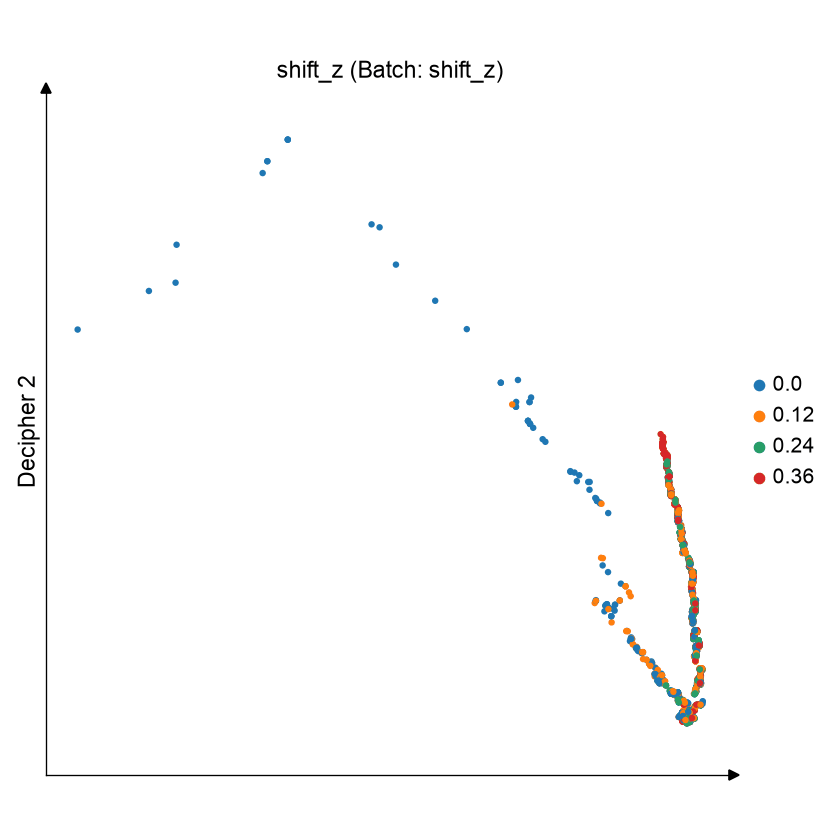

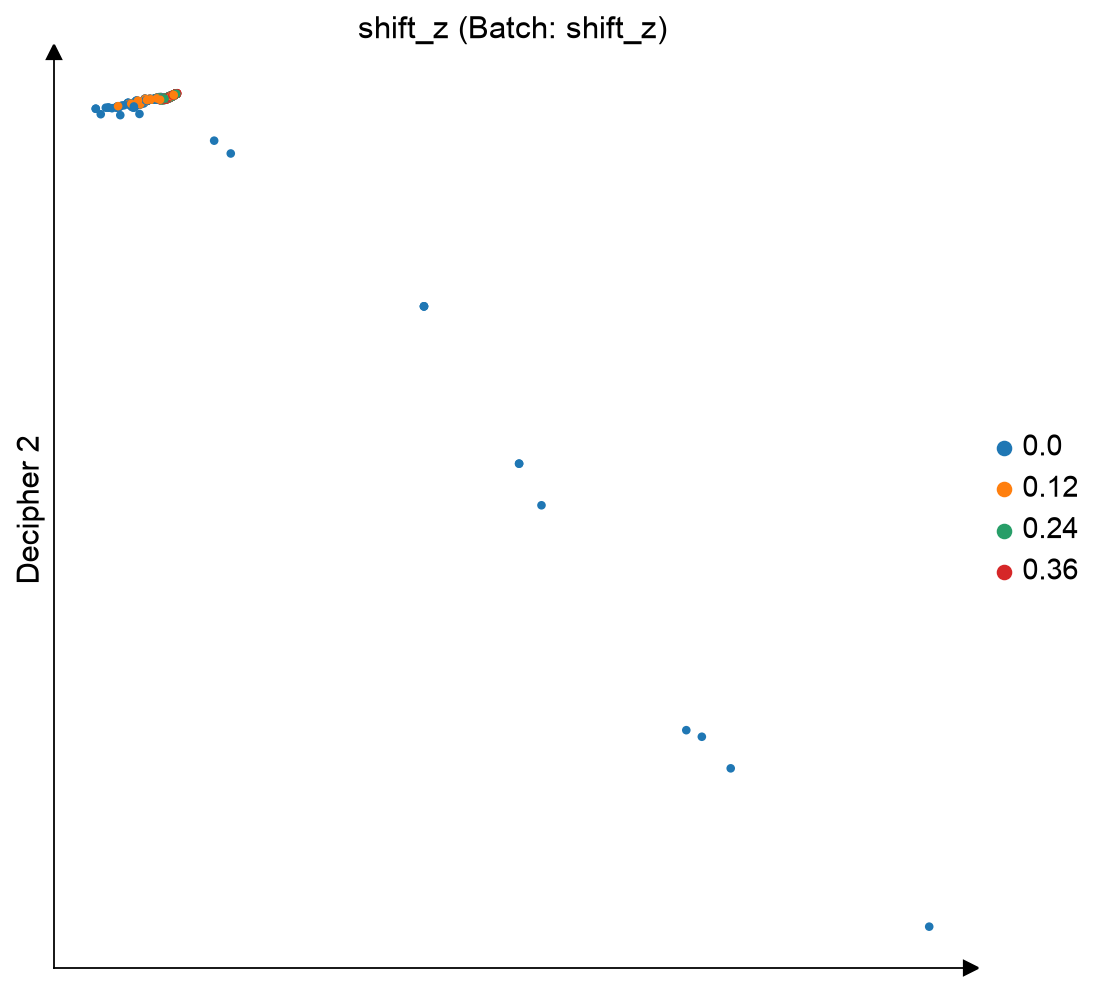

In [6]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

adata_vz = adata.copy()
d_vz, val_vz = dc_vz.tl.decipher_train(
    adata_vz, decipher_config,
    plot_kwargs={"color": "shift_z"},
    batch_key="shift_z",
    plot_every_k_epochs=5,
)

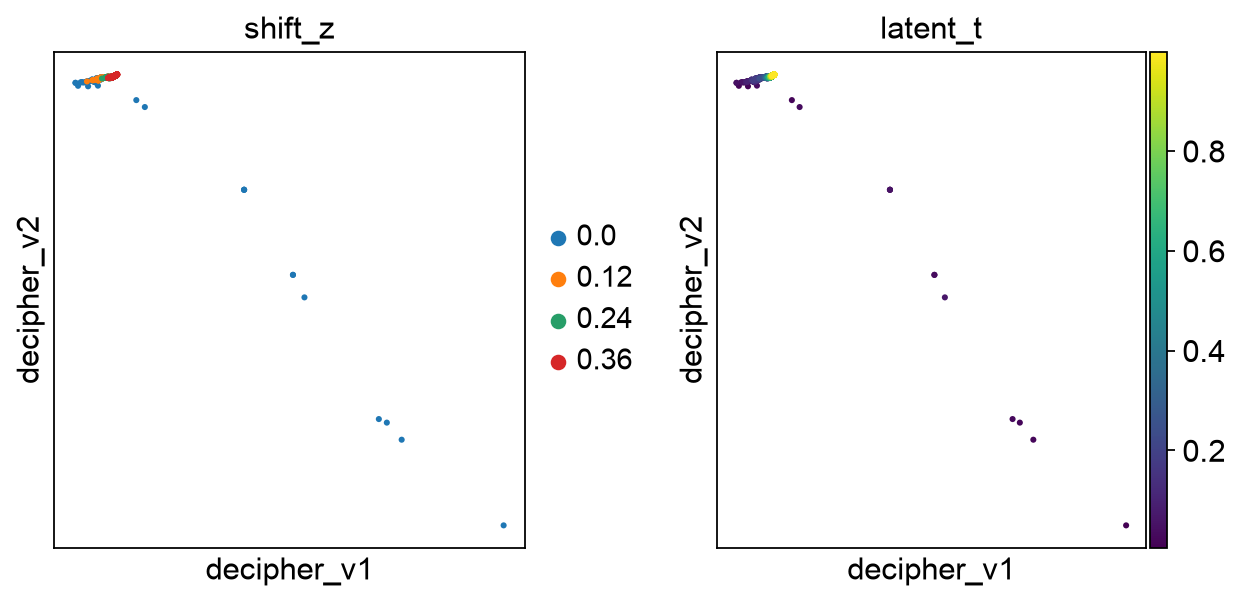

In [7]:
# Plot decipher_v — shift_z groups should be visible here (v captures biology + batch)
# REMOVED: cluster_true column (no branching in v2 → no ground-truth clusters)
# REPLACED WITH: latent_t (ground-truth pseudotime) as the biological reference
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_vz, basis="decipher_v", color="shift_z",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_vz, basis="decipher_v", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

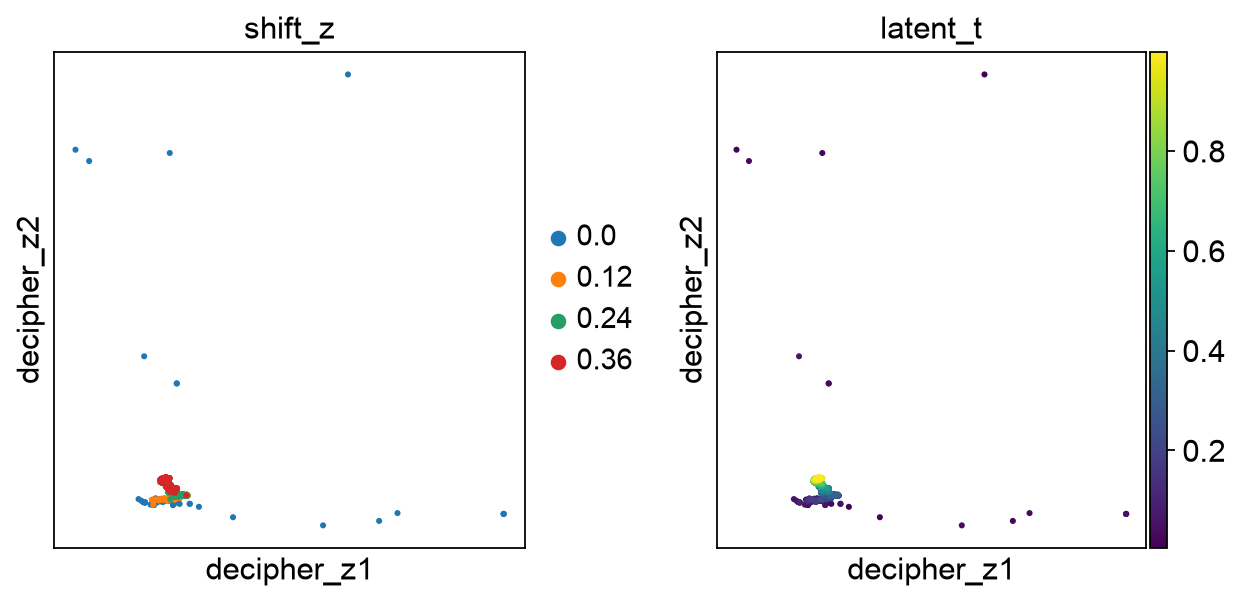

In [8]:
# Plot decipher_z — batch correction happens here.
# Shift groups should be less separated in z than in v if the model is working.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_vz, basis="decipher_z", color="shift_z",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_vz, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [9]:
# REMOVED: ARI (adjusted_rand_score) vs cluster_true — no ground-truth clusters in v2
# REPLACED WITH: Spearman correlation of decipher_v[:,0] vs latent_t
#   Higher correlation = model recovers the true pseudotime ordering

v_vz = adata_vz.obsm["decipher_v"]

print("── Spearman correlation: decipher_v vs latent_t (per shift_z) ──────────")
for s in sorted(adata_vz.obs["shift_z"].unique()):
    mask = adata_vz.obs["shift_z"] == s
    rho, pval = spearmanr(v_vz[mask, 0], adata_vz.obs["latent_t"][mask])
    print(f"  shift_z={s:<6}  rho={rho:+.4f}  p={pval:.2e}")

── Spearman correlation: decipher_v vs latent_t (per shift_z) ──────────
  shift_z=0.0     rho=+0.8494  p=2.42e-140
  shift_z=0.12    rho=+0.9842  p=0.00e+00
  shift_z=0.24    rho=+0.9780  p=0.00e+00
  shift_z=0.36    rho=+0.9805  p=0.00e+00


In [10]:
from sklearn.metrics import silhouette_score

# REMOVED: adata_combined reference (was a broken reference in notebook 6)
# REPLACED WITH: adata_vz (the trained adata from this notebook)

v = adata_vz.obsm["decipher_v"].copy()
labels = adata_vz.obs["shift_z"].astype(str)

print("── Silhouette score in v-space (lower = better batch correction) ────────")
score = silhouette_score(v, labels, sample_size=5000, random_state=42)
print(f"  shift_z  silhouette = {score:.4f}")

── Silhouette score in v-space (lower = better batch correction) ────────
  shift_z  silhouette = -0.2174
